# Galaxy Evolution Simulator
ASTR6002 Assignment 6 

In [1]:
import numpy as np 
import astropy.units as u
import matplotlib.pyplot as plt

The class below provides everything to simulate + plot a galaxy's evolution.
Initialize with: 
- timestep `dt`
- starting gas mass `m_gas`
- star formation extinction time `t_ex`
- gas infall stopping time `t_stop`
- gas infall rate `infall_rate`
- fraction of stars that die in a timestep `z_yield`
- mass-fraction of alpha elements returned to gas `a_yield`
- mass-fraction of iron-group elements returned to gas `fe_yield`
- mass fraction of metal-rich gas retained in galaxy `f_retain`
- whether AGN will blow out all gas at t=1.5 Gyr `agn`

Then use `galaxy.evolution()` to run the simulation, and `galaxy.plot_everything()` for plots

### Equations used for calculation

Gas and stellar mass:
$$
\begin{split}   
    M_\text{gas, new} &= M_\text{gas, old} + \Delta t \left(\frac{dM_\text{infall}}{dt} + \text{SFR}_\text{old}(\text{yield} \cdot \text{f}_\text{retain} - 1) \right) \\
    M_\text{star, new} &= M_\text{star, old} + \Delta t \cdot \text{SFR}_\text{old} (1  - \text{yield} \cdot \text{f}_\text{retain} ) \\
\end{split}
$$

Star formation: 
$$
\text{SFR}_{\text{new}} = \frac{M_{\text{gas, new}}}{t_{ex}}
$$

Total metallicity:
$$
\begin{split} 
    Z_{\text{gas, new}} &=  (M_{\text{gas, old}}Z_{\text{gas, old}} + \Delta t \cdot\text{SFR}_{\text{old}} [Z_{\text{gas, old}} + f_{retain} \cdot yield ] ) \cdot M_{\text{gas, new}}^{-1} \\
    Z_{\text{star, new}} &= ( M_\text{star, old} \cdot Z_\text{star, old} +  \text{SFR}_\text{old} \cdot \Delta t \cdot Z_\text{gas, old}) \cdot M_{\text{star, new}}^{-1}
\end{split}
$$

Alpha-element mass fraction:
$$
\begin{split} 
    \alpha_{\text{gas, new}}  &= Z_{\text{gas, new}} \cdot \alpha_\text{yield}\\
    \alpha_{\text{star, new}} &= \frac{(M_\text{gas, old} \cdot \alpha_{\text{star, old}}) + (\text{SFR}_\text{old} \cdot \Delta t \cdot \alpha_{\text{gas, old}})} {M_{\text{star, new}}}\\
\end{split}
$$

Iron-group mass fraction:
$$
\begin{split}
    \text{Fe}_{\text{gas, new}} &= Z_{\text{gas, new}} \cdot \text{Fe}_\text{yield}\\
    \text{Fe}_{\text{star, new}} &= \frac{(M_\text{gas, old} \cdot \text{Fe}_{\text{star, old}}) + (\text{SFR}_\text{old} \cdot \Delta t \cdot \text{Fe}_{\text{gas, old}})}{M_{\text{star, new}}}\\
\end{split}
$$


In [45]:
class galaxy:
    def __init__(self, dt, m_gas, t_ex, t_stop, infall_rate, z_yield, a_yield, fe_yield, f_retain, agn=False):
        """initial conditions and parameters
        
        Parameters
        ----------
            dt: `float`
                timestep size (Gyr)
            m_gas: `int`
                initial gas mass (Msun)
            t_ex: `int | float`
                exhaustion timescale for star formation (Gyr)
            t_stop: `int | float`
                time that gas infall stops (Gyr)
            infall_rate: `int | float`
                rate of gas infall into galaxy (Msun / yr)
            z_yield: `float`
                rate of star death (must be <1)
            a_yield: `float`
                mass fraction of alpha-elements returned to gas by short-lived stars.
                this is generally between 0.2 - 0.4
            fe_yield: `float`
                mass fraction of iron-elements returned to gas by long-lived stars after 1 Gyr
                this is generally between 0.05 - 0.1
            f_retain: `float`
                mass fraction of metal-rich gas retained in the galaxy (1-f_retain is blown out)
            agn: `boolean`
                activate AGN-induced heating at t = 1.5 Gyr (default false)
            """
        
        # timesteps and time array
        self.dt = dt * u.Gyr
        self.timesteps = np.arange(20, step=dt)                   # timesteps
        
        # masses of gas and stars
        self.mass_gas = np.zeros_like(self.timesteps) * u.Msun    # gas mass (Msun)
        self.mass_gas[0] = m_gas * u.Msun                         # initial mass
        self.mass_star = np.zeros_like(self.mass_gas)             # stellar mass (Msun)
        self.mass_infall = np.zeros_like(self.mass_gas)           # mass of infalling gas
        
        # metallicity
        self.z_gas = np.zeros_like(self.timesteps)                # average gas metallicity
        self.z_stars = np.zeros_like(self.timesteps)              # average star metallicity
        
        self.a_yield = a_yield                                    # mass fraction of a-elements returned to gas
        self.a_gas = np.zeros_like(self.timesteps)
        self.a_stars = np.zeros_like(self.timesteps)
        self.a_enhancement = np.zeros_like(self.timesteps)        # relative alpha enhancement (a_stars/f_stars) * (f_yield/a_yield)
        
        self.fe_yield = fe_yield                                  # mass fraction of Fe-elements returned to gas (only >1 Gyr)
        self.fe_gas = np.zeros_like(self.timesteps)
        self.fe_stars = np.zeros_like(self.timesteps)
        self.fe_content = np.zeros_like(self.timesteps)           # relative iron content fe_stars / fe_chosen
        
        self.f_retain = f_retain                                  # fraction of metal-rich gas that stays in galaxy
        
        # star formation rate, controlled by extinction time
        self.sfr = np.empty_like(self.timesteps) * (u.Msun / u.yr)  # SFR (Msun / yr)
        self.t_ex = t_ex * u.Gyr 
        self.factor = 1 / self.t_ex.to(u.yr)
        
        # apply units
        self.timesteps *= u.Gyr
        self.t_stop = t_stop * u.Gyr 
        self.infall_rate = infall_rate * (u.Msun / u.yr)
        self.z_yield = z_yield 
        self.agn = agn
        pass
    
    def evolution(self):
        """runs through galaxy evolution simulation"""
        for i, time in enumerate(self.timesteps):
            if i == 0:
                self.sfr[i] = self.mass_gas[i] * self.factor
                continue
            
            # stars dying removes star mass, adds gas mass
            # note: this could be controlled by its own parameter instead of SFR...
            dead_stars = self.z_yield * self.sfr[i-1] * self.dt
            if self.mass_star[i-1] == 0:
                dead_stars = 0 * u.Msun
            self.mass_star[i] = self.mass_star[i-1] - dead_stars
            self.mass_gas[i] = self.mass_gas[i-1] + (dead_stars * self.f_retain)

            # new gas added via infall
            if time <= self.t_stop:
                self.mass_infall[i] = self.infall_rate * self.dt
            self.mass_gas[i] += self.mass_infall[i]
            
            # set gas mass to zero when agns are on
            if self.agn and time >= 1.5*u.Gyr:
                self.mass_gas[i] = 0 * u.Msun
                self.mass_infall[i] = 0 * u.Msun

            # SFR this timestep based on existing gas mass
            self.sfr[i] = self.mass_gas[i] * self.factor
            new_stars = self.sfr[i-1] * self.dt

            # only make new stars if there is enough gas for it
            if self.mass_gas[i-1] > new_stars:
                self.mass_star[i] += new_stars
                self.mass_gas[i]  -= new_stars

            # gas metallicity = (prev metallicity * (prev gas - new stars) + dead star mass) / total current gas mass
            if self.mass_gas[i] > 0 * u.Msun:
                self.z_gas[i] = (self.z_gas[i-1] * (self.mass_gas[i-1] - new_stars) + dead_stars) / self.mass_gas[i]
            self.a_gas[i] = self.z_gas[i] * self.a_yield
            # only introduce iron after 1 Gyr
            if time >= (1 * u.Gyr):
                self.fe_gas[i] = self.z_gas[i] * self.fe_yield
            
            # star metallicity = (prev metallicity * prev stars + new stars * prev gas metallicity) / total current star mass
            self.z_stars[i] = (self.z_stars[i-1] * self.mass_star[i-1] + new_stars*self.z_gas[i-1]) / self.mass_star[i]
            self.a_stars[i] = (self.a_stars[i-1] * self.mass_star[i-1] + new_stars*self.a_gas[i-1]) / self.mass_star[i]
            self.fe_stars[i] = (self.fe_stars[i-1] * self.mass_star[i-1] + new_stars*self.fe_gas[i-1]) / self.mass_star[i]
            
            # metallicity content
            self.fe_content[i] = self.fe_stars[i] / self.fe_yield
            if self.fe_stars[i] > 0:
                self.a_enhancement[i] = (self.a_stars[i]/self.fe_stars[i]) * (self.fe_yield/self.a_yield)
                        
    def plot_everything(self, maxtime=3.0):
        """plots stellar mass, gas mass, star formation, and metallicity over time
        
        Parameters
        ----------
            maxtime: `int | float`
                maximum time to plot up to (Gyr, default = 3)
        """
        
        fig, ax = plt.subplots(2, 3, figsize=(12,8), sharex=True)
        timerange = self.timesteps.value <= maxtime

        # mass evolution
        ax[0,0].plot(self.timesteps[timerange], self.mass_gas[timerange], label=r"$M_{gas}$")
        ax[0,0].plot(self.timesteps[timerange], self.mass_star[timerange], label=r"$M_{stars}$")
        ax[0,0].set(xlabel="Time (Gyr)", ylabel=r"Mass ($M_{\odot}$)", title=f"Mass evolution")
        ax[0,0].legend()
        ax[0,0].grid(True)
        
        # metallicity evolution
        ax[0,1].plot(self.timesteps[timerange], self.z_gas[timerange], label=r"$z_{gas}$")
        ax[0,1].plot(self.timesteps[timerange], self.z_stars[timerange], label=r"$z_{stars}$")
        ax[0,1].set(xlabel="Time (Gyr)", ylabel="Metallicity Z", title=f"Metallicity evolution")
        ax[0,1].legend()
        ax[0,1].grid(True)
        
        # star formation evolution
        ax[0,2].plot(self.timesteps[timerange], self.sfr[timerange])
        ax[0,2].set(xlabel="Time (Gyr)", ylabel=r"SFR ($M_{\odot} / yr$)", title="Star formation rate")
        ax[0,2].grid(True)
        

        # alpha and iron evolution
        ax[1,0].plot(self.timesteps[timerange], self.a_gas[timerange], label=r"$\alpha_{gas}$")
        ax[1,0].plot(self.timesteps[timerange], self.a_stars[timerange], label=r"$\alpha_{stars}$")
        ax[1,0].plot(self.timesteps[timerange], self.fe_gas[timerange], ls="--", label=r"$Fe_{gas}$")
        ax[1,0].plot(self.timesteps[timerange], self.fe_stars[timerange], ls="--", label=r"$Fe_{stars}$")
        ax[1,0].set(xlabel="Time (Gyr)", ylabel="Metal abundance", title=f"Alpha and Iron abundance")
        ax[1,0].legend()
        ax[1,0].grid(True)
        
        # alpha enhancement
        ax[1,1].plot(self.timesteps[timerange], self.a_enhancement[timerange], label=r"$\alpha$ enhance")
        ax[1,1].set(xlabel="Time (Gyr)", ylabel=r"[$\alpha$/Fe]", title=r"Alpha enhancement [$\alpha$/Fe]")
        ax[1,1].grid(True)
        
        # iron enhancement
        ax[1,2].plot(self.timesteps[timerange], self.fe_content[timerange], label="Fe content")
        ax[1,2].set(xlabel="Time (Gyr)", ylabel="[Fe/H]", title="Iron content [Fe/H]")
        ax[1,2].grid(True)
        
        plt.tight_layout()
        plt.show()
        
        

### 3.b: Milky Way-like Galaxy

Parameters:
- initial gas mass = $10^{10} M_{\odot}$
- gas infall rate = $7 M_{\odot} / yr$, t_stop >> 14
- gas retention fraction = 1
- z yield = 0.02
- alpha yield = 0.005
- fe yield = 0.002
- star formation exhaustion time = 3 Gyr

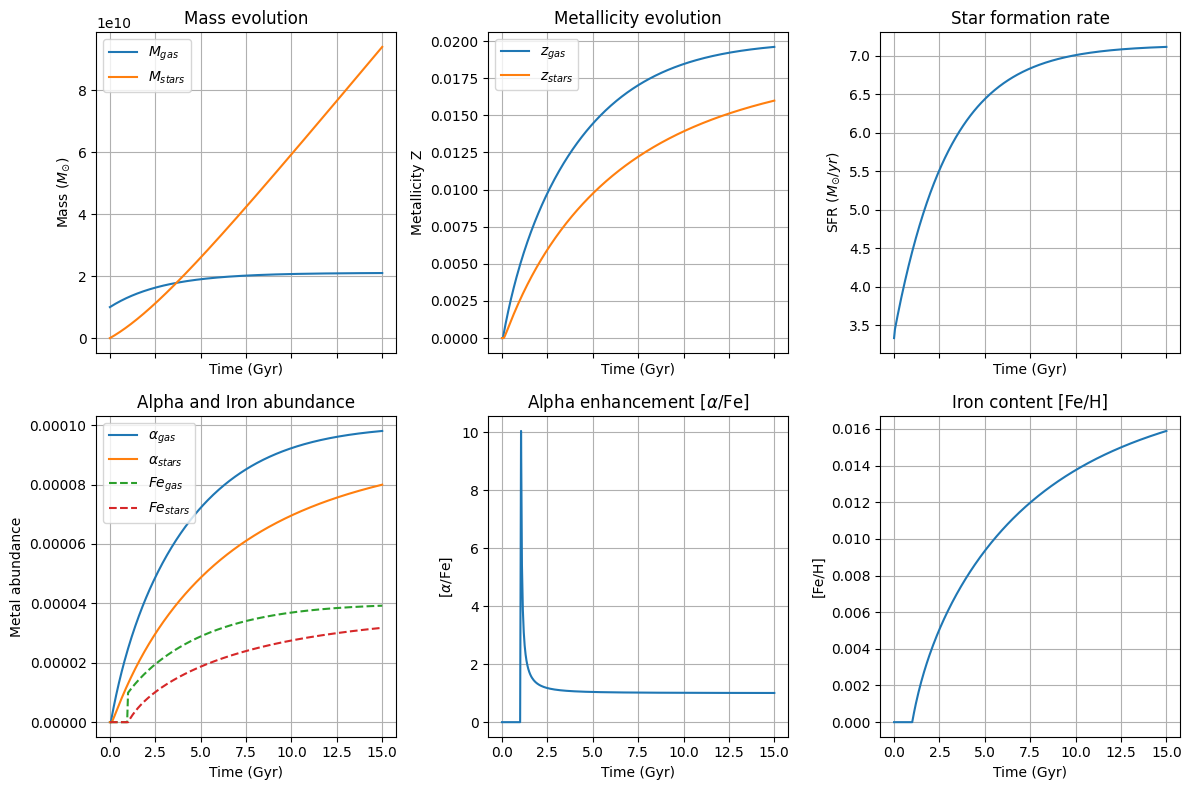

In [46]:
spiral = galaxy(dt=0.05, m_gas=1e10, t_ex=3, t_stop=31, infall_rate=7, z_yield=0.02, a_yield=0.005, fe_yield=0.002, f_retain=1)
spiral.evolution()
spiral.plot_everything(15)

### 3.c: Elliptical Galaxy

Parameters:
- initial gas mass = $10^{10} M_{\odot}$
- gas infall rate = $1000 M_{\odot} / yr$, t_stop = 0.3 Gyr
- gas retention fraction = 1
- z yield = 0.02
- alpha yield = 0.005
- fe yield = 0.002
- star formation exhaustion time = 0.5 Gyr

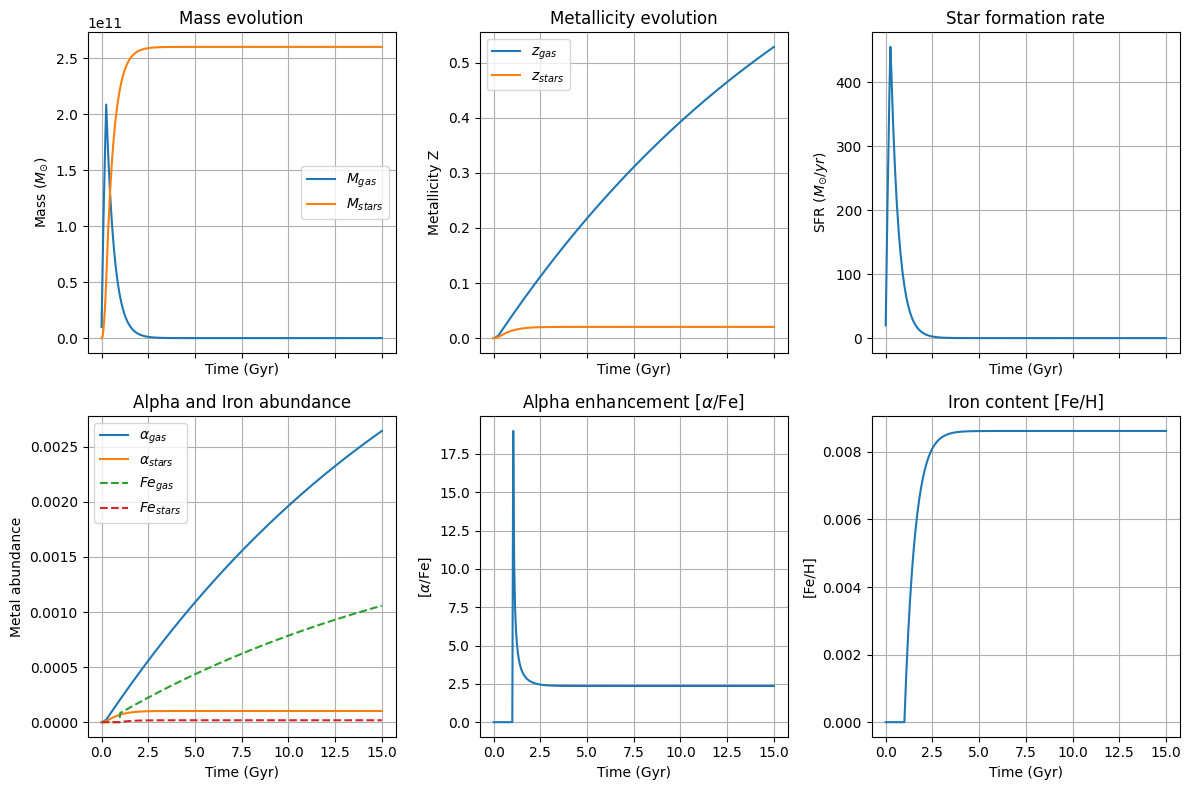

In [47]:
elliptical = galaxy(dt=0.05, m_gas=1e10, t_ex=0.5, t_stop=0.3, infall_rate=1000, z_yield=0.02, a_yield=0.005, fe_yield=0.002, f_retain=1)
elliptical.evolution()
elliptical.plot_everything(15)

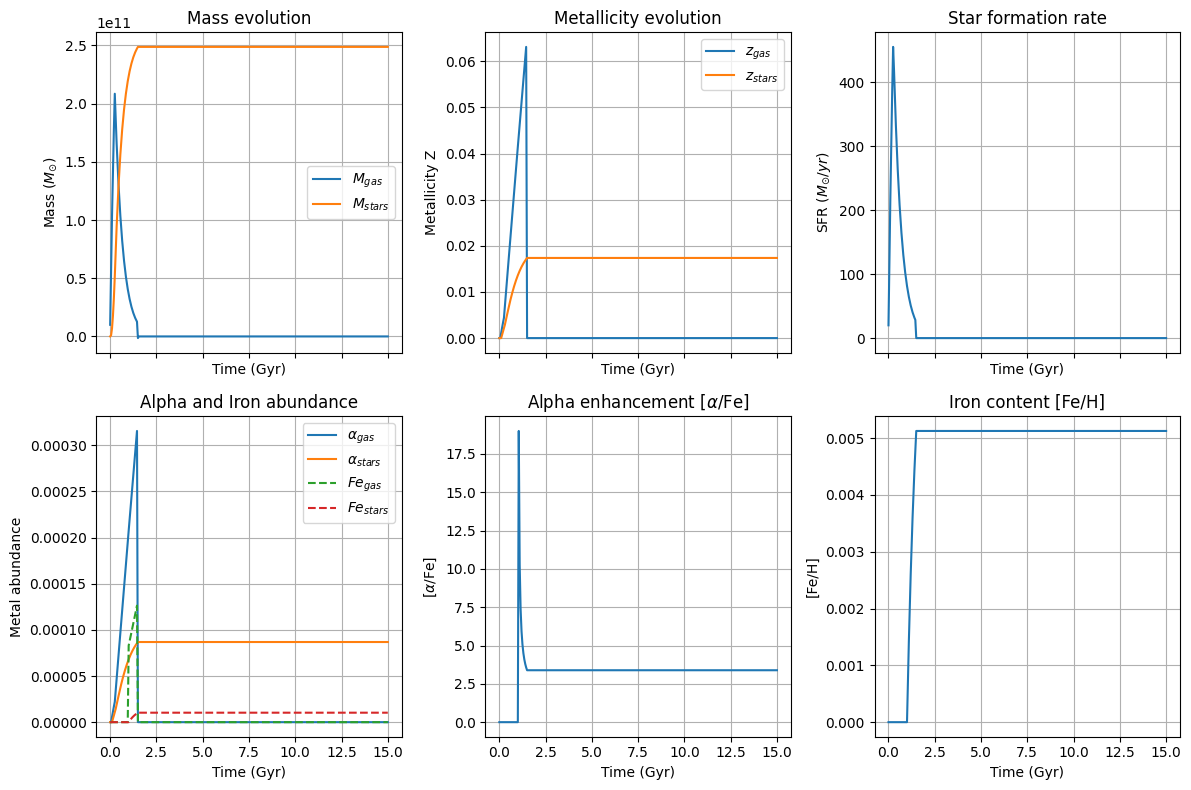

In [49]:
# AGN elliptical
elliptical_agn = galaxy(dt=0.05, m_gas=1e10, t_ex=0.5, t_stop=0.3, infall_rate=1000, z_yield=0.02, a_yield=0.005, fe_yield=0.002, f_retain=1, agn=True)
elliptical_agn.evolution()
elliptical_agn.plot_everything(15)

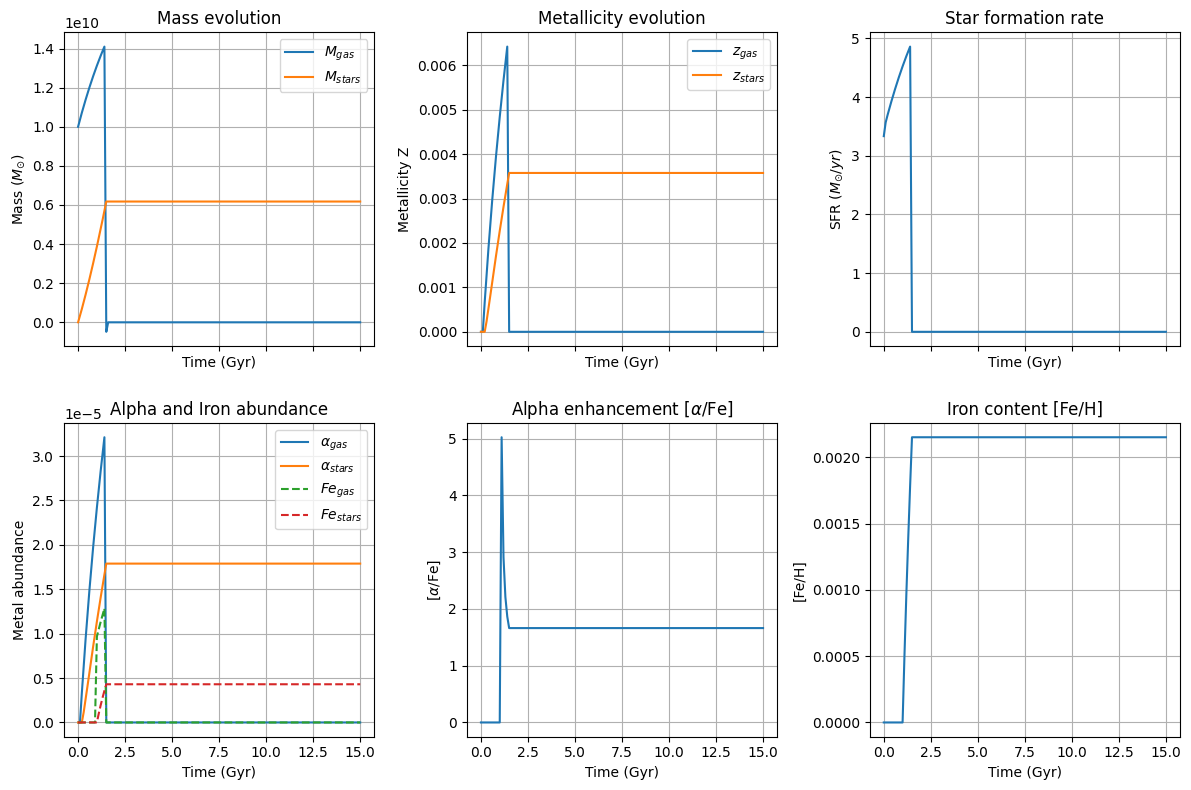

In [50]:
# AGNs on
spiral_agn = galaxy(dt=0.05, m_gas=1e10, t_ex=3, t_stop=31, infall_rate=7, z_yield=0.02, a_yield=0.005, fe_yield=0.002, f_retain=1, agn=True)
spiral_agn.evolution()
spiral_agn.plot_everything(15)

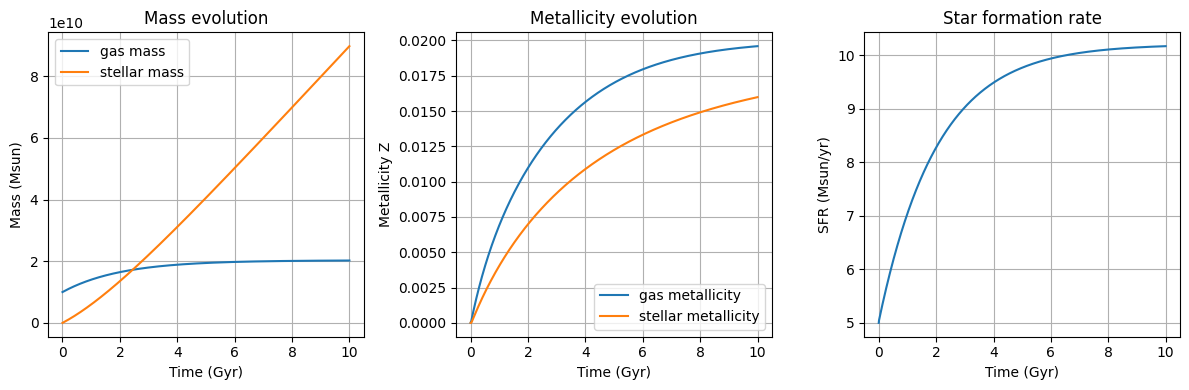

In [4]:
# never-ending gas infall
workshop_3 = galaxy(0.01, 1e10, 2, 14, 10, 0.02)
workshop_3.evolution()
workshop_3.plot_everything(10)

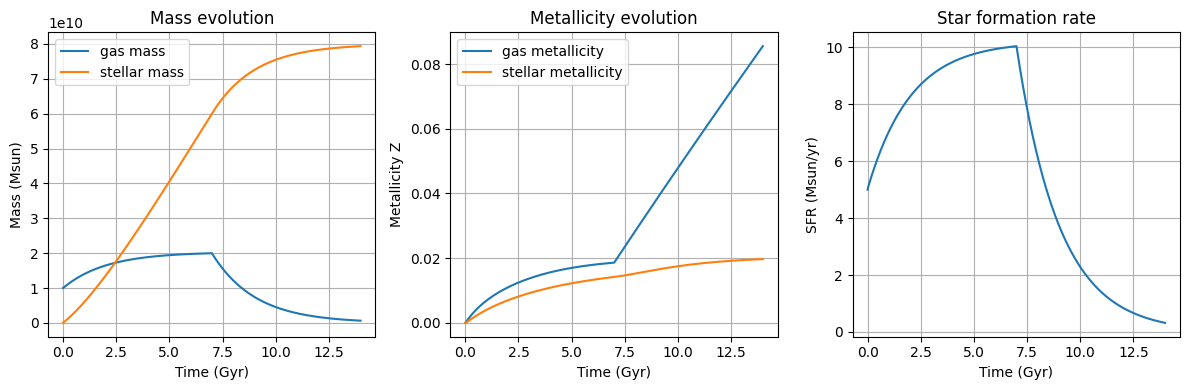

In [5]:
# gas infall stops after 7 Gyr
workshop_4 = galaxy(0.01, 1e10, 2, 7, 10, 0.02)
workshop_4.evolution()
workshop_4.plot_everything(14)